# Empirical results

**4.1. Descriptive results**
- 4.1.1. Magnitude of the drift (Figure 2)
- 4.1.2. Relation of drift to firm size (Figure 3, 4)
- 4.1.3. Longevitiy of the drift (Table 1)

**4.2. Test of risk premiums as explanation for the drift**
- 4.2.1. Shifts in Betas
- 4.2.2. ATP risk factors as potential explanation
- 4.2.3. Consistent profitability of the strategy
- 4.2.4. Raw returns on bad news firms

**4.3. Tests of transactions costs as explanation for drift**
- 4.3.1. Upper bound constraint
- 4.3.2. Abnormal returns: long VS short

**4.4. Tests of whether prices fail to reflect full implication of current earnings for future earnings**

## **4.1. Descriptive results**
### **4.1.1. Magnitude of the drift**

***FIG. 2.-Cumulative abnormal returns (CARs) for SUE portfolios: all announcements.***


*Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution. Based on 84,792 announcements from 1974 to 1986. CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile. SUE represents forecast errors from a first-order autoregressive earnings expectation model (in seasonal differences) scaled by its estimation-period standard deviation (see section 3.2 for details).*

Result: a long D1 - short D10 strat would yield a 4.2% abnormal return over the 60 days subsequent period (18%). It's 17% for the continuously balanced SUE.

- We need to compute CAR (cumulated Abnormal returns). CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile
- Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution.

We begin by loading SUE filtered quartered.

In [1]:
import pandas as pd
import numpy as np

df_sue_final = pd.read_csv("../data/SUE.csv")
df_sue_final['datadate'] = pd.to_datetime(df_sue_final['datadate'])
df_sue_final['gvkey'] = df_sue_final['gvkey'].astype(str)

We then assign SUE deciles based in prior-quarter distribution to avoid any hindsight bias that would magnify the drift.

In [2]:
df_sue_final['prev_fyearq'] = np.where(df_sue_final['fqtr'] == 1, df_sue_final['fyearq'] - 1, df_sue_final['fyearq'])
df_sue_final['prev_fqtr']   = np.where(df_sue_final['fqtr'] == 1, 4, df_sue_final['fqtr'] - 1)

# Compute decile boundaries from prior-quarter distribution
decile_bounds = (
    df_sue_final.groupby(['fyearq', 'fqtr'])['SUE']
    .quantile(np.arange(0.1, 1.0, 0.1))
    .unstack()
    .reset_index()
    .rename(columns={'fyearq': 'prev_fyearq', 'fqtr': 'prev_fqtr'})
)
# Rename quantile columns to avoid float key issue
decile_bounds.columns = ['prev_fyearq', 'prev_fqtr'] + [f'd{i}' for i in range(1, 10)]

df_sue_final = df_sue_final.merge(decile_bounds, on=['prev_fyearq', 'prev_fqtr'], how='left')

# Vectorized decile assignment using boundary columns
bound_cols = [f'd{i}' for i in range(1, 10)]
bounds_arr = df_sue_final[bound_cols].values
sue_arr    = df_sue_final['SUE'].values

# For each row, count how many boundaries the SUE exceeds → decile
df_sue_final['SUE_decile'] = (sue_arr[:, None] > bounds_arr).sum(axis=1) + 1

print(df_sue_final['SUE_decile'].value_counts().sort_index())

SUE_decile
1     8659
2     8184
3     8534
4     8361
5     8536
6     8261
7     8459
8     8420
9     8320
10    8578
Name: count, dtype: int64


We now compute Cumulative Abnormal Returns (CAR) on the -60,+60 days window surrounding an earnings announcement.

In [3]:
dfD = pd.read_csv("../data/dfD_final.csv")

# For each firm-quarter, get the list of trading days around rdq
dfD['DlyCalDt'] = pd.to_datetime(dfD['DlyCalDt'])
df_sue_final['rdq'] = pd.to_datetime(df_sue_final['rdq'])

# Merge dfD with df_sue_final on PERMNO to get all daily returns per firm
dfD_small = dfD[['PERMNO', 'DlyCalDt', 'DlyAbnReturn']].copy()
dfD_small = dfD_small.sort_values(['PERMNO', 'DlyCalDt'])
dfD_small['day_rank'] = dfD_small.groupby('PERMNO').cumcount()

rdq_ranks = df_sue_final[['gvkey', 'PERMNO', 'rdq', 'SUE_decile']].merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_rank'})

events = rdq_ranks[['gvkey', 'PERMNO', 'rdq', 'rdq_rank', 'SUE_decile']].dropna(subset=['rdq_rank'])
events['rdq_rank'] = events['rdq_rank'].astype(int)

# We filter before the merge
events['rank_min'] = events['rdq_rank'] - 60
events['rank_max'] = events['rdq_rank'] + 60

# Merge then filter
car_df = events.merge(dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'day_rank']], on='PERMNO', how='left')
car_df['rel_day'] = car_df['day_rank'] - car_df['rdq_rank']
car_df = car_df[(car_df['rel_day'] >= -60) & (car_df['rel_day'] <= 60)]

car_df = car_df.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df['CAR'] = car_df.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

# Average CAR by decile and relative day
car_avg = (
    car_df.groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

print(car_avg.head(10))
print(f"Deciles: {car_avg['SUE_decile'].unique()}")
print(f"Rel days: {car_avg['rel_day'].min()} to {car_avg['rel_day'].max()}")


   SUE_decile  rel_day       CAR
0           1      -60 -0.001263
1           1      -59 -0.002641
2           1      -58 -0.003576
3           1      -57 -0.003853
4           1      -56 -0.004102
5           1      -55 -0.004918
6           1      -54 -0.006575
7           1      -53 -0.007452
8           1      -52 -0.008512
9           1      -51 -0.010023
Deciles: [ 1  2  3  4  5  6  7  8  9 10]
Rel days: -60 to 60


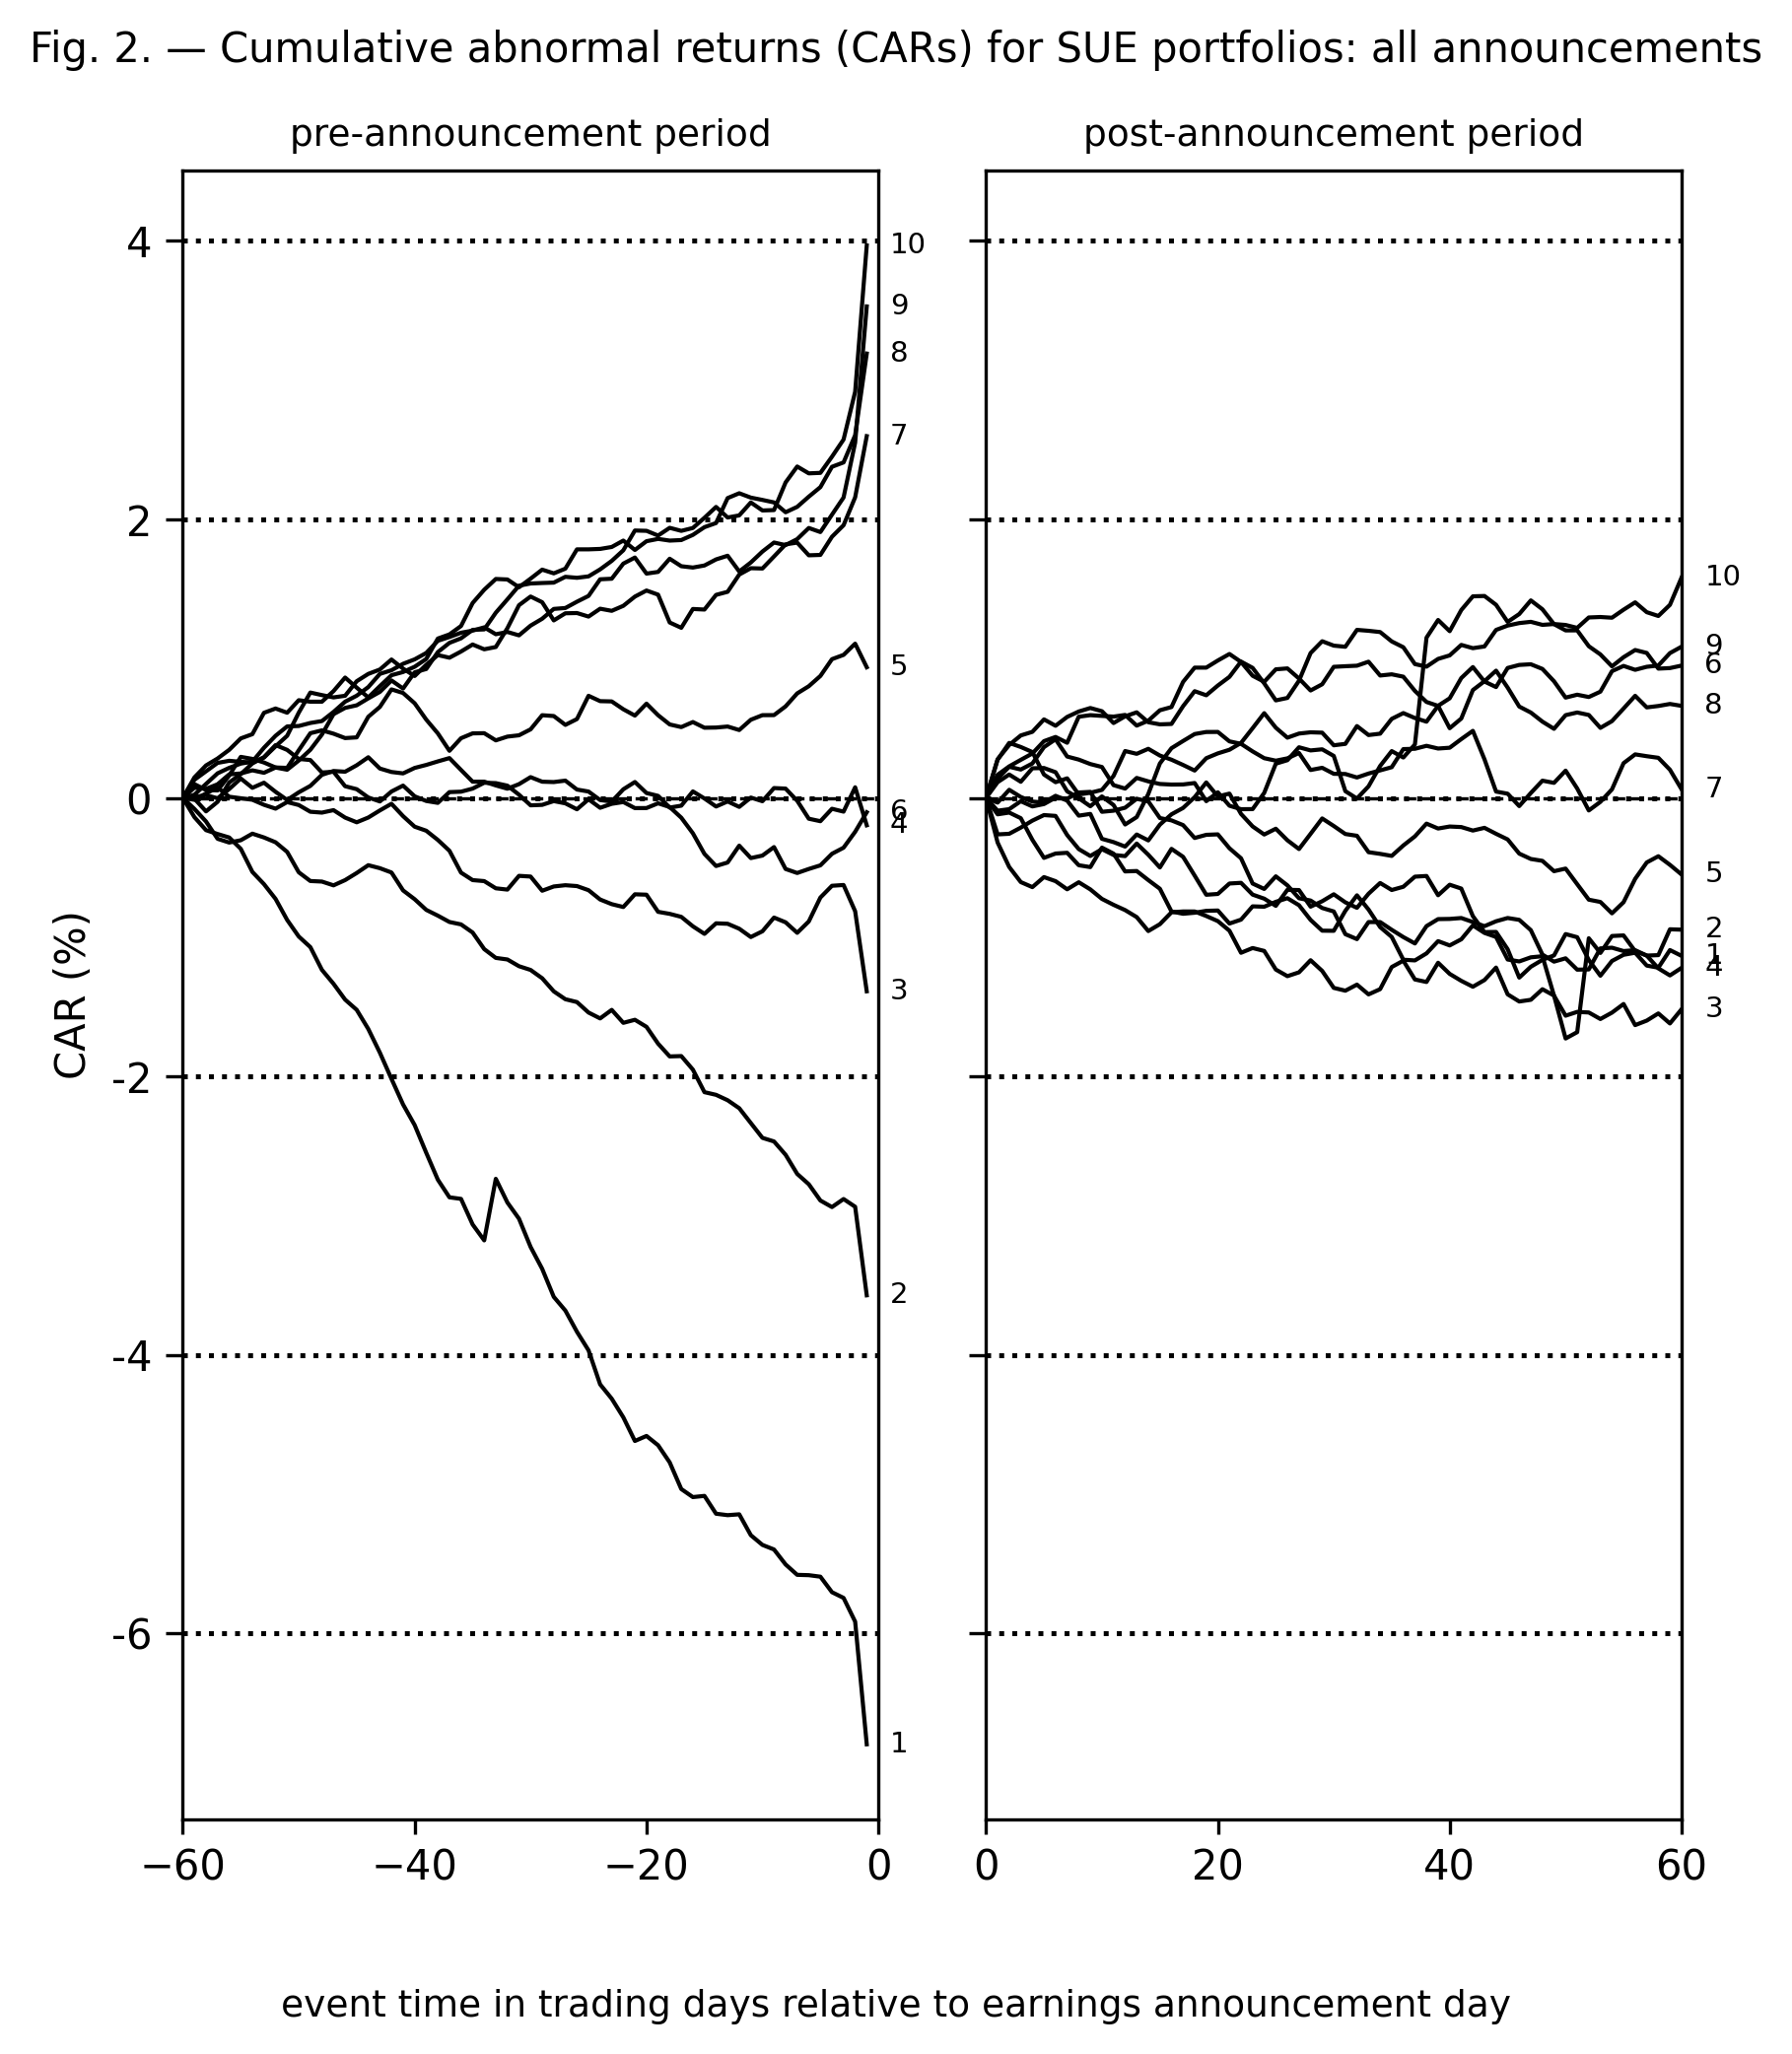

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=300)


for decile in range(1, 11):
    data = car_avg[car_avg['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 2. — Cumulative abnormal returns (CARs) for SUE portfolios: all announcements', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()